# 🧠 Lasso Regression (L1 Regularization)

## 📌 Objective
Apply Lasso Regression to reduce overfitting and observe feature selection.

## 📊 Dataset
Insurance dataset:
- age
- bmi
- children
- smoker
- region
- charges (target)

## ⚙️ Workflow
1. Load Data  
2. Preprocess Data  
3. Train Model  
4. Evaluate Performance  
5. Analyze Coefficients  

In [3]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# Load dataset
df = pd.read_csv("../../datasets/insurance.csv")

# Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
# Basic info
df.info()

# Statistical summary
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
# Convert categorical variables into numerical form
# drop_first=True avoids dummy variable trap

df = pd.get_dummies(df, drop_first=True)

df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [9]:
# Separate input features (X) and target variable (y)

X = df.drop("charges", axis=1)
y = df["charges"]

In [10]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# Create Lasso model
# alpha controls strength of regularization

lasso = Lasso(alpha=0.1)

# Train model
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [12]:
# Predict on test data

y_pred = lasso.predict(X_test)

In [13]:
# Calculate evaluation metrics

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 33597770.054583974
R2 Score: 0.7835874745529608


In [14]:
# Extract coefficients

coefficients = pd.Series(lasso.coef_, index=X.columns)

# Display coefficients
coefficients

age                   256.974934
bmi                   337.070238
children              425.208802
sex_male              -18.139778
smoker_yes          23650.493235
region_northwest     -369.059930
region_southeast     -656.168800
region_southwest     -808.161769
dtype: float64

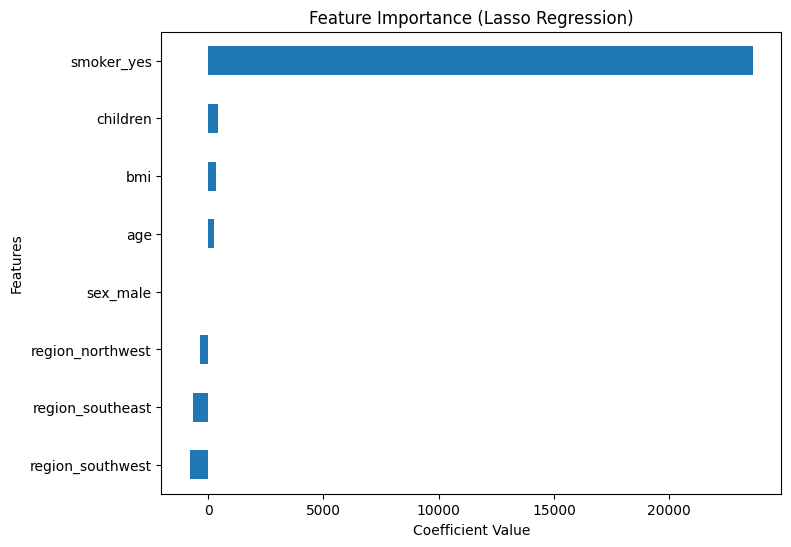

In [15]:
# Plot feature importance

coefficients.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance (Lasso Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.show()

In [16]:
# Automatically find best alpha using cross-validation

lasso_cv = LassoCV(cv=5)

lasso_cv.fit(X_train, y_train)

print("Best alpha (lambda):", lasso_cv.alpha_)

Best alpha (lambda): 89.2161025213486


In [17]:
# Train model using optimal alpha

lasso_best = Lasso(alpha=lasso_cv.alpha_)

lasso_best.fit(X_train, y_train)

# Predictions
y_pred_best = lasso_best.predict(X_test)

# Evaluation
print("R2 Score (Optimized):", r2_score(y_test, y_pred_best))

R2 Score (Optimized): 0.7796410202259697


## 📊 Observations

- Lasso reduces magnitude of coefficients  
- Some coefficients become exactly zero  
- Acts as feature selection technique  
- Helps reduce overfitting  

## ✅ Conclusion

- Lasso Regression uses L1 regularization  
- Useful when many features are present  
- Automatically removes less important features  
- Improves model generalization  